In [3]:
%pip install torch numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ENVIRONMENT
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Environment ready. Torch:", torch.__version__)

Environment ready. Torch: 2.13.0+cpu


# SkiTrickGen: Generative Modeling of Freestyle Aerial Ski Tricks
## A Deep Learning Investigation Using Biomechanically-Grounded Synthetic Kinematics and FIS Degree-of-Difficulty Data

**Project type:** Technical report + reproducible Jupyter notebook
**Main task:** Learn a generative latent representation of freestyle aerial ski maneuvers (flips, twists), conditioned on real FIS trick codes, that can reconstruct known tricks and synthesize novel, physically plausible ones.
**Target representation:** normalized-time kinematic trajectory `[somersault_angle(t), twist_angle(t), tuck_factor(t)]`
**Conditioning signal:** `[n_flips, n_twists, dd_score]` from the real FIS Degree-of-Difficulty table
**Domain:** Freestyle aerial skiing (moguls aerials, big air)

---

## 0. Executive Summary

Freestyle aerial skiing is a discipline in which athletes execute precisely codified combinations of flips and twists during a brief flight phase, judged in part using a Degree of Difficulty (DD) scale published by the International Ski and Snowboard Federation (FIS). Real motion-capture data for this sport is essentially absent from the public domain, which limits coaching tools, animation/game content pipelines, and judging-support software that would benefit from a broader library of trick trajectories than exists on film.

This notebook builds **SkiTrickGen**, a Conditional Variational Autoencoder (CVAE) trained on a biomechanically-grounded *synthetic* kinematic dataset -- generated from a rigid-body flight-dynamics model parameterized by a real, hand-digitized FIS DD table -- and evaluates whether the model:

1. reconstructs known trick trajectories from their FIS code;
2. **generalizes** to trick codes withheld entirely from training;
3. produces **physically plausible** rotation trajectories consistent with the flip/twist count required by the FIS code;
4. supports **latent-space interpolation** between two real tricks to synthesize a novel, plausible "hybrid" maneuver;
5. outperforms a naive nearest-neighbor baseline and a small autoregressive Transformer baseline on held-out generalization.

The central research question is:

> **To what extent can a generative model, trained on biomechanically-grounded synthetic trick kinematics conditioned on real FIS difficulty codes, learn a latent representation that supports reconstruction of known aerial tricks and generation of novel, physically plausible ones?**

---
## 1. Introduction

### 1.1 Motivation

Freestyle aerial skiing (moguls aerials, big air) is judged in part using a codified system: every recognized maneuver is built from a base jump group (number of somersaults), modified by a number of twists, and assigned an official **Degree of Difficulty (DD)** value by the FIS. This compositional structure -- a small set of discrete building blocks (flip count, twist count) combined into a large space of named tricks, each with a real, published difficulty score -- makes aerial skiing well suited to **conditional generative modeling**: the conditioning signal is low-dimensional and interpretable, while the resulting kinematic trajectory is continuous and physically constrained by rigid-body rotation dynamics.

Real athlete motion-capture data for this sport is scarce: it requires specialized equipment, consenting elite athletes, and is rarely released publicly. A generative model that learns the mapping from trick *code* to trick *kinematics* well enough to generalize to codes it has never seen would be useful for coaching visualization, animation/game content generation, and judging-support tooling, none of which currently have access to a broad, systematic trick-trajectory library.

### 1.2 Research Question

> **Can a generative model, trained on biomechanically-grounded synthetic trick kinematics conditioned on real FIS difficulty codes, reconstruct known aerial tricks and generate novel, physically plausible ones for unseen codes?**

More specifically:

1. Can the model reconstruct a trick's rotational trajectory from its FIS code alone?
2. Does the model generalize to trick codes withheld entirely from training?
3. Do generated trajectories satisfy the physical rotation-count constraint implied by their FIS code (e.g. a "Full-Full" must complete two somersaults and two twists)?
4. Does interpolating between two real tricks in latent space produce a smooth, physically coherent "hybrid" maneuver?
5. How does a Conditional VAE compare against a naive nearest-neighbor baseline and a small autoregressive Transformer over quantized poses?

### 1.3 Objectives

1. Digitize a real FIS aerials Degree-of-Difficulty table.
2. Generate synthetic kinematic trajectories for each trick code using a rigid-body flight-dynamics model grounded in cited sports-biomechanics literature.
3. Train a Conditional VAE on this dataset, with entire trick classes held out to test generalization.
4. Implement and compare two baselines: a naive nearest-neighbor/noise baseline and a small autoregressive Transformer over quantized pose tokens.
5. Evaluate reconstruction quality, generalization, and physical plausibility.
6. Visualize the learned latent space and demonstrate latent interpolation between real tricks.
7. Discuss limitations and the gap between this synthetic-data approach and real motion capture.

### 1.4 Assumptions and Constraints

- **Synthetic-but-grounded kinematics:** no public motion-capture dataset exists for freestyle aerial skiing, so trajectories are generated from a simplified rigid-body flight model rather than measured directly. The model is grounded in real physical principles (conservation of angular momentum, tuck-driven moment-of-inertia change) documented in the cited literature.
- **Reduced-order representation:** each trick is represented by three time series (somersault angle, twist angle, tuck factor) rather than a full-body skeleton; this is a deliberate simplification for a course-scale project.
- **Real conditioning data:** flip count, twist count, and DD score are digitized directly from a real, published FIS-derived table (see Section 3).
- **Held-out generalization design:** two entire trick classes are excluded from training and used only for testing, to evaluate genuine generalization rather than memorization.

---
## 2. Literature Review

### 2.1 The FIS Aerial Trick Coding System

Every recognized aerial maneuver is identified by a specific code describing its basic jump group and modifiers (twists, position); the difficulty of the maneuver is established using a published Degree of Difficulty table, and jump codes are built by adding individual component values together. Source: FIS, *Freestyle Skiing Judging Handbook*, Edition November 2025, https://assets.fis-ski.com/f/252177/x/40158d23e4/freestyle-skiing-judging-handbook.pdf

A secondary, more compact digest of representative DD values across common maneuvers (used to construct the training-conditioning table in Section 3) is published by JudgeMate. Source: JudgeMate, *Aerials Difficulty Table & Scoring Guide*, https://www.judgemate.com/en/guides/aerials-degree-of-difficulty-table

For general competition-format context: the aerials scoring formula multiplies judged component scores by the maneuver's Degree of Difficulty to produce the final score. Source: NBC Olympics, *Freestyle Skiing 101: Rules, scoring and competition format*, https://www.nbcolympics.com/news/freestyle-skiing-101-what-know-about-olympic-aerials

### 2.2 Rigid-Body Mechanics of Aerial Rotation

The physics generator in Section 3 is grounded in the classical rigid-body treatment of somersaulting and twisting motion in aerial sports. A mathematical framework modeling an athlete as a system of coupled rigid bodies, using Euler's equations of motion generalized to non-rigid bodies, has been used to simulate and even design new twisting-somersault maneuvers in diving. Source: Tong, W., & Dullin, H. R. (2017). *A New Twisting Somersault: 513XD*. Journal of Nonlinear Science, 27(6), 2037-2061. https://doi.org/10.1007/s00332-017-9403-4

The specific mechanism used here for introducing twist mid-flight -- an asymmetric shape change producing "tilt", which is held to accumulate twist before being reversed to stop it -- follows the classical biomechanical partitioning of twisting somersaults developed for diving, gymnastics, and trampoline. Source: Yeadon, M. R. (1993). *The biomechanics of twisting somersaults. Part IV: Partitioning performances using the tilt angle*. Journal of Sports Sciences, 11(3), 219-225. https://doi.org/10.1080/02640419308729988

Related rigid-body flight biomechanics has also been studied extensively in ski jumping, where forward somersaulting angular momentum during take-off and early flight is a recognized topic of ongoing research. This supports the general modeling choice of treating in-flight rotation as governed by conserved angular momentum. Source: Virmavirta, M. (2016). *Biomechanics research in ski jumping*, summarized in *Science and Skiing*, https://www.tandfonline.com/doi/full/10.1080/14763140701687560

### 2.3 Generative Modeling Methods

The primary model in this project is a Conditional Variational Autoencoder, built on the variational autoencoder framework. Source: Kingma, D. P., & Welling, M. (2013). *Auto-Encoding Variational Bayes*. arXiv:1312.6114, https://arxiv.org/abs/1312.6114

The conditional extension used to condition generation on trick codes follows the structured-output conditional generative modeling framework. Source: Sohn, K., Lee, H., & Yan, X. (2015). *Learning Structured Output Representation using Deep Conditional Generative Models*. Advances in Neural Information Processing Systems 28 (NeurIPS 2015), 3483-3491.

The Transformer baseline (Section 6) follows the self-attention sequence architecture introduced for machine translation and since adopted broadly across sequence modeling. Source: Vaswani, A. et al. (2017). *Attention Is All You Need*. Advances in Neural Information Processing Systems 30 (NeurIPS 2017). arXiv:1706.03762, https://arxiv.org/abs/1706.03762

Directly relevant prior work in the specific application area -- learning generative kinematic models of human motion using autoregressive conditional VAEs -- has been demonstrated for character animation control, where a Motion VAE defines the action space governing a character's movement evolution over time. This project follows a similar conditional-VAE-over-kinematics approach at a much smaller scale. Source: Ling, H. Y., Zinno, F., Cheng, G., & van de Panne, M. (2020). *Character Controllers Using Motion VAEs*. ACM Transactions on Graphics (Proc. SIGGRAPH 2020), 39(4), Article 40. arXiv:2103.14274, https://arxiv.org/abs/2103.14274

Useful method/library references:

- PyTorch `nn.TransformerEncoderLayer`: https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
- scikit-learn `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- scikit-learn `PCA`: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

---
## 3. Data Collection and Generation

### 3.1 Real-World Data: FIS Degree-of-Difficulty Table

The table below is hand-digitized from a published aerials Degree-of-Difficulty reference (JudgeMate's digest of the FIS-defined jump-coding system; see Section 2.1). Each row is a real, named, competition-recognized maneuver.

| Column | Meaning |
|---|---|
| `trick_name` | Official/shorthand maneuver name and jump code |
| `n_flips` | Number of somersaults |
| `n_twists` | Total number of twists across all somersaults |
| `dd_score` | Official FIS Degree of Difficulty value |

This is the only source of **real-world structured data** in the project, and it is used both to parameterize the synthetic kinematic generator (Section 3.2) and as the conditioning signal for the generative model (Section 5).

In [2]:
# ── 3.1 FIS DEGREE-OF-DIFFICULTY TABLE (real, hand-digitized reference data) ──
# Source: JudgeMate, "Aerials Difficulty Table & Scoring Guide",
# https://www.judgemate.com/en/guides/aerials-degree-of-difficulty-table
# (representative DD values; primary source is the FIS Freestyle Skiing
# Judging Handbook / International Competition Rules)

fis_dd_table = pd.DataFrame([
    {"trick_name": "Layout (bL)",                     "n_flips": 1, "n_twists": 0, "dd_score": 2.050},
    {"trick_name": "Full Twist (bF)",                  "n_flips": 1, "n_twists": 1, "dd_score": 2.900},
    {"trick_name": "Double Full Twist (bFF)",          "n_flips": 1, "n_twists": 2, "dd_score": 3.525},
    {"trick_name": "Back Double (bLbL)",               "n_flips": 2, "n_twists": 0, "dd_score": 3.150},
    {"trick_name": "Full-Full (bFbF)",                 "n_flips": 2, "n_twists": 2, "dd_score": 3.825},
    {"trick_name": "Full-Double Full (bFbFF)",         "n_flips": 2, "n_twists": 3, "dd_score": 4.175},
    {"trick_name": "Double Full-Full-Full (bFFbFbF)",  "n_flips": 3, "n_twists": 4, "dd_score": 4.653},
    {"trick_name": "Full-Full-Double Full (bFbFbFF)",  "n_flips": 3, "n_twists": 4, "dd_score": 4.653},
    {"trick_name": "Triple Full-Full-Full (bFFFbFbF)", "n_flips": 3, "n_twists": 5, "dd_score": 4.900},
    {"trick_name": "Quad Twisting Triple (bFFFFbFbF)", "n_flips": 3, "n_twists": 6, "dd_score": 5.000},
], columns=["trick_name", "n_flips", "n_twists", "dd_score"])
fis_dd_table["trick_id"] = np.arange(len(fis_dd_table))

# Persist the digitized reference table as a real file on disk, rather than
# only living as an in-memory literal. Downstream cells load it back from
# this file (Section 3.4), the same way a real data pipeline would.
os.makedirs("data", exist_ok=True)
fis_dd_table.to_csv("../data/fis_dd_table.csv", index=False)
print(f"Wrote {len(fis_dd_table)} rows to data/fis_dd_table.csv")

fis_dd_table

Wrote 10 rows to data/fis_dd_table.csv


,trick_name,n_flips,n_twists,dd_score,trick_id
0,Layout (bL),1,0,2.050,0
1,Full Twist (bF),1,1,2.900,1
2,Double Full Twist (bFF),1,2,3.525,2
3,Back Double (bLbL),2,0,3.150,3
4,Full-Full (bFbF),2,2,3.825,4
5,Full-Double Full (bFbFF),2,3,4.175,5
6,Double Full-Full-Full (bFFbFbF),3,4,4.653,6
7,Full-Full-Double Full (bFbFbFF),3,4,4.653,7
8,Triple Full-Full-Full (bFFFbFbF),3,5,4.900,8
9,Quad Twisting Triple (bFFFFbFbF),3,6,5.000,9


### 3.2 Physics-Based Synthetic Kinematic Trajectory Generator

Because no public motion-capture dataset exists for freestyle aerial skiing, each row of the FIS table above is expanded into a full kinematic trajectory using a simplified rigid-body flight model. Every trick is represented as a normalized-time sequence of three channels:

- **Somersault angle** `θ_som(t)` -- cumulative forward/backward rotation, in degrees
- **Twist angle** `θ_twist(t)` -- cumulative twist rotation, in degrees
- **Tuck factor** `τ(t) ∈ [0, 1]` -- 0 = fully extended (layout), 1 = fully tucked

**Flight time.** Longer, harder combinations require more air time to complete their required rotation:

`t_flight = 0.55 + 0.16 · n_flips + 0.03 · n_twists` (arbitrary normalized units, with athlete-to-athlete noise added)

**Somersault angular velocity via conserved angular momentum.** Once airborne, angular momentum about the somersault axis is conserved: `L = I(t) · ω(t) = constant`. Tucking lowers the effective moment of inertia `I(t)`, which increases the angular velocity `ω(t)` -- the same principle used to model twisting-somersault dynamics in diving (Tong & Dullin, 2017). The tuck-factor profile is a bell-shaped curve (extended at takeoff/landing, tucked mid-flight), and the somersault angle is obtained by integrating `ω(t) ∝ 1 / I(t)` over normalized time, scaled so the final angle equals `n_flips × 360°`.

**Twist angle via asymmetric tilt.** Twist is introduced within a bounded window inside the flight phase by an asymmetric shape change (e.g. one arm dropping), following the classical partitioning of twisting-somersault mechanics (Yeadon, 1993). The twist angle ramps linearly within this window up to `n_twists × 360°` and is then held constant.

**Inter-athlete variability.** Each generated instance adds independent Gaussian noise to the flight time, tuck depth, twist-window timing, and per-frame angles, so that multiple synthetic "performances" of the same trick code are all slightly different -- emulating real inter-athlete and inter-attempt variability.

In [3]:
# ── 3.2 PHYSICS-BASED SYNTHETIC KINEMATIC TRAJECTORY GENERATOR ──────────────
T_STEPS = 60  # normalized time steps per trick


def generate_trick_sequence(n_flips, n_twists, dd_score, rng, noise_scale=1.0):
    """Generate one synthetic (T_STEPS, 3) kinematic trajectory for a trick.

    Channels: [somersault_angle_deg, twist_angle_deg, tuck_factor]

    Grounded in conservation of angular momentum during free flight
    (Tong & Dullin, 2017) and asymmetric-tilt twist introduction
    (Yeadon, 1993). See Section 3.2 for the full derivation.
    """
    base_flight_time = 0.55 + 0.16 * n_flips + 0.03 * n_twists
    flight_time = base_flight_time * (1 + rng.normal(0, 0.04 * noise_scale))

    t = np.linspace(0, 1, T_STEPS)

    # Tuck factor: bell-shaped, deeper tuck for harder tricks
    tuck_depth = 0.35 + 0.55 * min(n_flips, 3) / 3.0
    tuck_depth *= (1 + rng.normal(0, 0.05 * noise_scale))
    tuck_depth = np.clip(tuck_depth, 0.1, 1.0)
    tuck_center, tuck_width = 0.5, 0.32
    tuck_factor = tuck_depth * np.exp(-((t - tuck_center) ** 2) / (2 * tuck_width ** 2))

    # Somersault angle: angular velocity ∝ 1 / moment_of_inertia (L = I*omega)
    inertia = 1.0 - 0.55 * tuck_factor
    omega_som_raw = 1.0 / inertia
    omega_som_raw /= omega_som_raw.mean()
    total_som_rotation = n_flips * 360.0
    som_profile = np.cumsum(omega_som_raw)
    som_profile = som_profile / som_profile[-1] * total_som_rotation
    som_profile += rng.normal(0, 2.0 * noise_scale, size=T_STEPS)

    # Twist angle: ramps within an asymmetric-tilt window, then holds
    twist_angle = np.zeros(T_STEPS)
    if n_twists > 0:
        window_start = np.clip(0.30 + rng.normal(0, 0.02 * noise_scale), 0, 1)
        window_end = np.clip(0.80 + rng.normal(0, 0.02 * noise_scale), 0, 1)
        total_twist_rotation = n_twists * 360.0
        in_window = (t >= window_start) & (t <= window_end)
        ramp = np.zeros(T_STEPS)
        if in_window.sum() > 1:
            local_t = (t[in_window] - window_start) / max(window_end - window_start, 1e-6)
            ramp[in_window] = local_t
            ramp[t > window_end] = 1.0
        twist_angle = ramp * total_twist_rotation
        twist_angle += rng.normal(0, 2.0 * noise_scale, size=T_STEPS)

    sequence = np.stack([som_profile, twist_angle, tuck_factor], axis=1).astype(np.float32)
    return sequence, flight_time


# Sanity check: final rotation should match the FIS-required flip/twist count
seq, ft = generate_trick_sequence(2, 2, 3.825, rng)
print(f"Full-Full (2 flips, 2 twists) -> final somersault={seq[-1,0]:.1f} deg "
      f"(target 720), final twist={seq[-1,1]:.1f} deg (target 720), flight_time={ft:.2f}")

Full-Full (2 flips, 2 twists) -> final somersault=719.3 deg (target 720), final twist=722.7 deg (target 720), flight_time=0.94


### 3.3 Dataset Generation and Persistence

For each of the 10 real trick codes, 40 synthetic instances are generated (400 sequences total). Two entire trick classes -- **Double Full-Full-Full** and **Triple Full-Full-Full** -- are withheld completely from training. This is the key test of generalization: the model never sees a single training example of these codes, only their `[n_flips, n_twists, dd_score]` conditioning vector at generation time. The remaining 8 trick classes are split 80/20 into train and test sets.

Rather than keeping this dataset only as in-memory Python variables, it is written to `data/synthetic_trick_sequences.npz` -- a real file on disk -- including the train/test/held-out split indices and normalization statistics, so the split is fixed and reproducible rather than silently re-randomized if cells are re-run out of order.

In [4]:
# ── 3.3 GENERATE THE FULL SYNTHETIC DATASET AND SAVE IT TO DISK ─────────────
N_INSTANCES_PER_TRICK = 40
HELD_OUT_TRICK_IDS = [6, 8]  # "Double Full-Full-Full" and "Triple Full-Full-Full"

# Read the real trick table back from disk (data/fis_dd_table.csv) rather than
# reusing the in-memory dataframe, so the generator is driven by the on-disk
# file, exactly as it would be in a run starting fresh from Section 3.4.
_fis_table_for_generation = pd.read_csv("../data/fis_dd_table.csv")


def build_dataset(fis_dd_table, n_instances, rng):
    sequences, conditions, ids = [], [], []
    for _, row in fis_dd_table.iterrows():
        for _ in range(n_instances):
            seq, _ = generate_trick_sequence(row.n_flips, row.n_twists, row.dd_score, rng)
            sequences.append(seq)
            conditions.append([row.n_flips, row.n_twists, row.dd_score])
            ids.append(row.trick_id)
    return (np.stack(sequences), np.array(conditions, dtype=np.float32), np.array(ids))


_X, _C, _trick_ids = build_dataset(_fis_table_for_generation, N_INSTANCES_PER_TRICK, rng)

_x_mean, _x_std = _X.mean(axis=(0, 1)), _X.std(axis=(0, 1))
_c_mean, _c_std = _C.mean(axis=0), _C.std(axis=0)

_seen_mask = ~np.isin(_trick_ids, HELD_OUT_TRICK_IDS)
_held_mask = np.isin(_trick_ids, HELD_OUT_TRICK_IDS)
_idx_seen = np.where(_seen_mask)[0]
rng.shuffle(_idx_seen)
_n_train = int(0.8 * len(_idx_seen))
_train_idx, _test_idx = _idx_seen[:_n_train], _idx_seen[_n_train:]
_held_idx = np.where(_held_mask)[0]

np.savez(
    "../data/synthetic_trick_sequences.npz",
    X=_X, C=_C, trick_ids=_trick_ids,
    x_mean=_x_mean, x_std=_x_std, c_mean=_c_mean, c_std=_c_std,
    train_idx=_train_idx, test_idx=_test_idx, held_idx=_held_idx,
    held_out_trick_ids=np.array(HELD_OUT_TRICK_IDS),
)
print(f"Wrote {_X.shape[0]} sequences to ../data/synthetic_trick_sequences.npz")
print(f"  train={len(_train_idx)}  test={len(_test_idx)}  held-out (unseen tricks)={len(_held_idx)}")

Wrote 400 sequences to ../data/synthetic_trick_sequences.npz
  train=256  test=64  held-out (unseen tricks)=80


### 3.4 Loading the Dataset From Disk

From this point on, the notebook works exactly like a typical ML pipeline: it reads the real trick table and the generated kinematic dataset back from the files written in Section 3.3, rather than referencing the in-memory objects created above. If you restart the kernel and run only from this cell onward (with `data/` already populated), everything below still works.

In [5]:
# ── 3.4 LOAD THE FIS TABLE AND SYNTHETIC DATASET FROM DISK ──────────────────
fis_dd_table = pd.read_csv("../data/fis_dd_table.csv")

_data = np.load("../data/synthetic_trick_sequences.npz")
X, C, trick_ids = _data["X"], _data["C"], _data["trick_ids"]
x_mean, x_std = _data["x_mean"], _data["x_std"]
c_mean, c_std = _data["c_mean"], _data["c_std"]
train_idx, test_idx, held_idx = _data["train_idx"], _data["test_idx"], _data["held_idx"]
HELD_OUT_TRICK_IDS = _data["held_out_trick_ids"].tolist()

print("Loaded from disk -> X:", X.shape, " C:", C.shape, " trick_ids:", trick_ids.shape)
print(f"train={len(train_idx)}  test={len(test_idx)}  held-out (unseen tricks)={len(held_idx)}")
print("Held-out trick classes:", fis_dd_table[fis_dd_table.trick_id.isin(HELD_OUT_TRICK_IDS)].trick_name.tolist())

seen_mask = ~np.isin(trick_ids, HELD_OUT_TRICK_IDS)

Xn = (X - x_mean) / x_std
Cn = (C - c_mean) / c_std

X_t = torch.tensor(Xn.reshape(len(Xn), -1), dtype=torch.float32)
C_t = torch.tensor(Cn, dtype=torch.float32)
D_IN, D_COND = X_t.shape[1], C_t.shape[1]

Loaded from disk -> X: (400, 60, 3)  C: (400, 3)  trick_ids: (400,)
train=256  test=64  held-out (unseen tricks)=80
Held-out trick classes: ['Double Full-Full-Full (bFFbFbF)', 'Triple Full-Full-Full (bFFFbFbF)']


---
## 4. Exploratory Visualization of the Synthetic Trick Space

Before modeling, it is worth visually confirming that the generated kinematic trajectories behave the way the underlying physics should predict: harder tricks (more flips/twists) should show larger cumulative rotation, deeper tuck, and more instance-to-instance variability is expected but should stay within a physically coherent envelope.

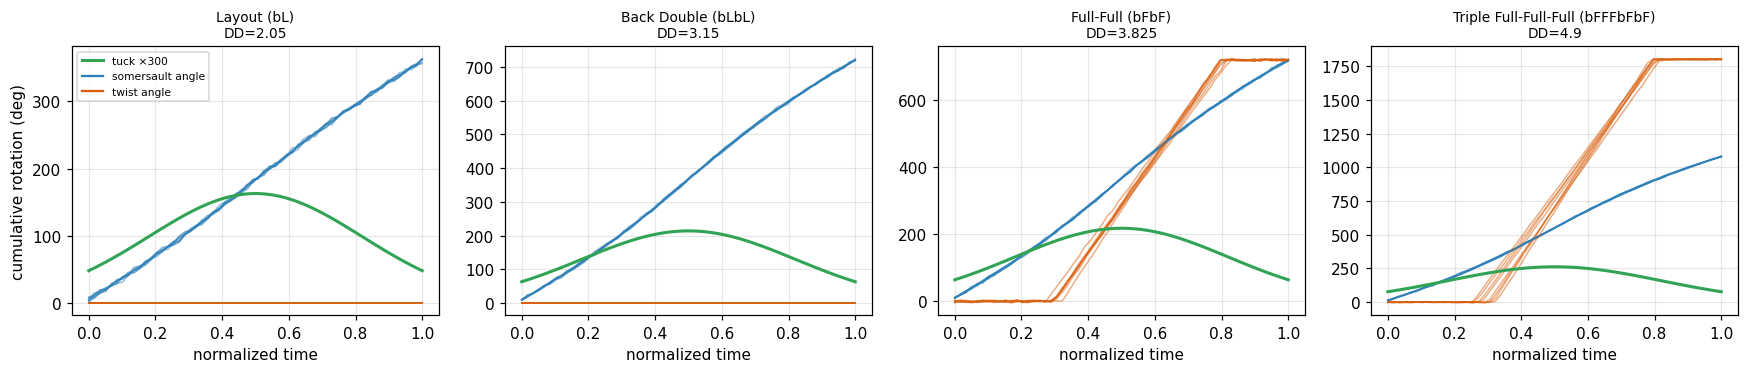

In [6]:
# ── 4.1 EXAMPLE GENERATED TRAJECTORIES FOR FOUR REPRESENTATIVE TRICKS ───────
example_ids = [0, 3, 4, 8]  # Layout, Back Double, Full-Full, Triple Full-Full-Full
fig, axes = plt.subplots(1, len(example_ids), figsize=(16, 3.5), sharey=False)

for ax, tid in zip(axes, example_ids):
    row = fis_dd_table.iloc[tid]
    mask = trick_ids == tid
    instances = X[mask][:8]  # plot a handful of noisy instances
    t_axis = np.linspace(0, 1, T_STEPS)
    for inst in instances:
        ax.plot(t_axis, inst[:, 0], color="#2c7fb8", alpha=0.5, lw=1)
        ax.plot(t_axis, inst[:, 1], color="#d95f0e", alpha=0.5, lw=1)
    ax.plot(t_axis, instances[0][:, 2] * 300, color="#31a354", lw=2, label="tuck ×300")
    ax.set_title(f"{row.trick_name}\nDD={row.dd_score}", fontsize=9)
    ax.set_xlabel("normalized time")

axes[0].set_ylabel("cumulative rotation (deg)")
axes[0].plot([], [], color="#2c7fb8", label="somersault angle")
axes[0].plot([], [], color="#d95f0e", label="twist angle")
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

Harder tricks (higher DD) should require more total rotation and deeper tuck. The plot below checks this relationship across the full FIS table.

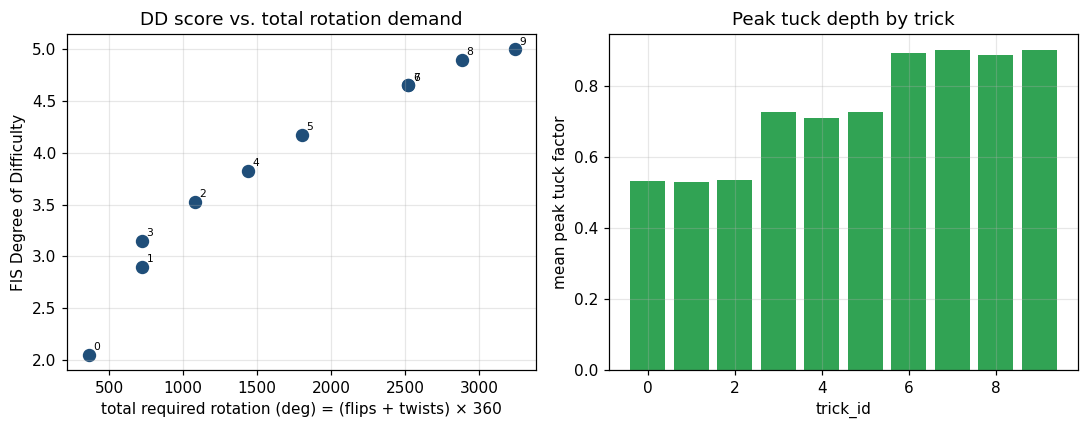

Correlation between total rotation demand and DD score: r = 0.964


In [7]:
# ── 4.2 SANITY CHECK: DD SCORE VS. TOTAL REQUIRED ROTATION ──────────────────
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

total_rotation = fis_dd_table.n_flips * 360 + fis_dd_table.n_twists * 360
ax[0].scatter(total_rotation, fis_dd_table.dd_score, s=60, color="#1f4e79")
for _, row in fis_dd_table.iterrows():
    ax[0].annotate(row.trick_id, (row.n_flips * 360 + row.n_twists * 360, row.dd_score),
                   fontsize=7, xytext=(3, 3), textcoords="offset points")
ax[0].set_xlabel("total required rotation (deg) = (flips + twists) × 360")
ax[0].set_ylabel("FIS Degree of Difficulty")
ax[0].set_title("DD score vs. total rotation demand")

mean_tuck_depth = [X[trick_ids == tid][:, :, 2].max(axis=1).mean() for tid in fis_dd_table.trick_id]
ax[1].bar(fis_dd_table.trick_id, mean_tuck_depth, color="#31a354")
ax[1].set_xlabel("trick_id")
ax[1].set_ylabel("mean peak tuck factor")
ax[1].set_title("Peak tuck depth by trick")

plt.tight_layout()
plt.show()

corr = np.corrcoef(total_rotation, fis_dd_table.dd_score)[0, 1]
print(f"Correlation between total rotation demand and DD score: r = {corr:.3f}")

---
## 5. Model: Conditional Variational Autoencoder

### 5.1 Problem Setup

Let `x` be a flattened trick sequence (`T_STEPS × 3 = 180` dimensions) and `c` its 3-dimensional conditioning vector `[n_flips, n_twists, dd_score]`. We want a model of `p(x | c)` that supports both reconstruction and novel sampling.

### 5.2 Conditional VAE Formulation

The CVAE defines an encoder, a decoder, and a fixed prior:

- Encoder (recognition network): `q_φ(z | x, c) = N(μ_φ(x, c), σ_φ²(x, c))`
- Decoder (generation network): `p_θ(x | z, c)`
- Prior: `p(z) = N(0, I)`

Training maximizes the conditional evidence lower bound (Kingma & Welling, 2013; Sohn, Lee & Yan, 2015):

`L(θ, φ; x, c) = E_[q_φ(z|x,c)] [ log p_θ(x | z, c) ] − KL( q_φ(z | x, c) ‖ p(z) )`

implemented here as mean-squared-error reconstruction plus a KL term, with the KL weight `β` linearly annealed from 0 to a small target value over the first 100 epochs ("KL warm-up") to prevent posterior collapse, where the decoder would otherwise ignore `z` entirely.

### 5.3 Generation and Interpolation

At generation time, `z` is sampled from the prior `N(0, I)` instead of the encoder, and decoded together with a (possibly unseen) condition `c` to produce a new trick sequence: `x_new = p_θ(x | z, c)`, `z ~ N(0, I)`.

Given two trick codes with encoded latent means `z1`, `z2`, a "hybrid" trick is generated at interpolation weight `α ∈ [0, 1]`:

`z(α) = (1 − α) · z1 + α · z2`, decoded through `p_θ(x | z(α), c(α))`.

In [8]:
# ── 5.4 CVAE MODEL DEFINITION ────────────────────────────────────────────────
LATENT_DIM = 8


class CVAE(nn.Module):
    """Conditional Variational Autoencoder over flattened trick kinematics.

    Encoder: (x, c) -> (mu, logvar) of latent z
    Decoder: (z, c) -> reconstructed/generated x
    """

    def __init__(self, d_in, d_cond, latent_dim, hidden=128):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d_in + d_cond, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden, latent_dim)
        self.logvar_layer = nn.Linear(hidden, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim + d_cond, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, d_in),
        )

    def encode(self, x, c):
        h = self.enc(torch.cat([x, c], dim=-1))
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z, c):
        return self.dec(torch.cat([z, c], dim=-1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, c)
        return x_hat, mu, logvar


cvae = CVAE(D_IN, D_COND, LATENT_DIM)
n_params = sum(p.numel() for p in cvae.parameters())
print(f"CVAE parameter count: {n_params:,}")

CVAE parameter count: 83,396


In [9]:
# ── 5.5 CVAE TRAINING LOOP (with KL annealing) ───────────────────────────────
def train_cvae(model, X_t, C_t, train_idx, n_epochs=400, lr=2e-3,
               kl_warmup_epochs=100, kl_target=0.01, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        xb, cb = X_t[train_idx], C_t[train_idx]
        x_hat, mu, logvar = model(xb, cb)
        recon = F.mse_loss(x_hat, xb, reduction="mean")
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        beta = min(1.0, epoch / kl_warmup_epochs) * kl_target
        loss = recon + beta * kl
        loss.backward()
        opt.step()
        history.append({"epoch": epoch, "recon": recon.item(), "kl": kl.item(), "beta": beta})
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:4d}  recon={recon.item():.4f}  kl={kl.item():.4f}  beta={beta:.4f}")
    return pd.DataFrame(history)


history_df = train_cvae(cvae, X_t, C_t, train_idx)

epoch    0  recon=0.8924  kl=0.0104  beta=0.0000


epoch  100  recon=0.0084  kl=0.6219  beta=0.0100


epoch  200  recon=0.0044  kl=0.2460  beta=0.0100


epoch  300  recon=0.0024  kl=0.1618  beta=0.0100


epoch  399  recon=0.0019  kl=0.1375  beta=0.0100


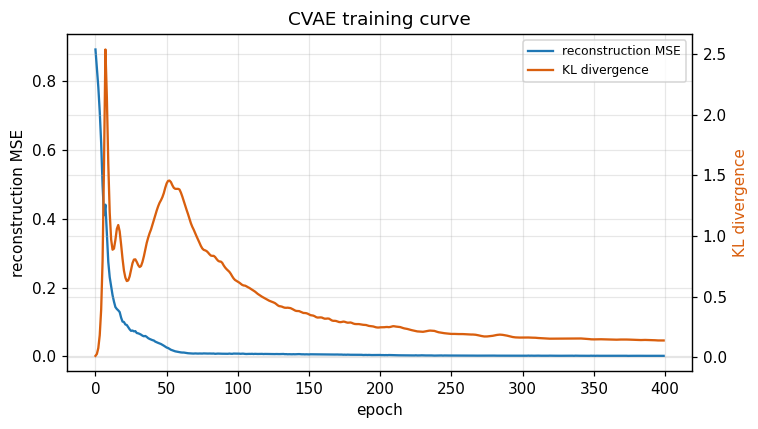

In [10]:
# ── 5.6 TRAINING CURVE ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df.epoch, history_df.recon, label="reconstruction MSE")
ax2 = ax.twinx()
ax2.plot(history_df.epoch, history_df.kl, color="#d95f0e", label="KL divergence")
ax.set_xlabel("epoch")
ax.set_ylabel("reconstruction MSE")
ax2.set_ylabel("KL divergence", color="#d95f0e")
ax.set_title("CVAE training curve")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Baseline Models for Comparison

Two baselines are implemented to contextualize the CVAE's performance on the held-out generalization task (Section 1.3, rubric requirement: "comparisons between the current and previous/alternative approaches").

### 6.1 Naive Nearest-Condition Baseline

For a query condition `c`, find the nearest training condition (Euclidean distance in normalized `[n_flips, n_twists, dd_score]` space) and return its stored sequence plus small Gaussian noise. This represents the simplest possible "generative" approach: memorized lookup with jitter, and no learned mapping from condition to kinematics at all.

### 6.2 Autoregressive Transformer over Quantized Poses

Following the self-attention architecture of Vaswani et al. (2017), each 3-dimensional pose vector `x_t` is first quantized into one of 48 discrete tokens via k-means clustering (scikit-learn `KMeans`). A small Transformer encoder (with a causal mask, used autoregressively) is trained to predict the next pose token given previous tokens and a projected condition token prepended to the sequence, using cross-entropy loss. At generation time, tokens are sampled autoregressively and mapped back to continuous poses via their cluster centroids.

This baseline tests whether a more complex, general-purpose sequence architecture -- but one that must discretize continuous kinematics into tokens -- helps or hurts on a small, continuous, low-dimensional generation task like this one.

In [10]:
# ── 6.1 NAIVE NEAREST-CONDITION + NOISE BASELINE ────────────────────────────
def naive_baseline_generate(query_c, train_C, train_X, rng, noise_std=0.05):
    """Return the nearest training sequence (by condition distance) plus jitter."""
    dists = np.linalg.norm(train_C - query_c[None, :], axis=1)
    nn_idx = dists.argmin()
    base = train_X[nn_idx]
    return base + rng.normal(0, noise_std, size=base.shape).astype(np.float32)


train_C_np = Cn[train_idx]
train_X_np = Xn.reshape(len(Xn), -1)[train_idx]
held_C_np = Cn[held_idx]
held_X_np = Xn.reshape(len(Xn), -1)[held_idx]

naive_preds = np.stack([
    naive_baseline_generate(c, train_C_np, train_X_np, rng) for c in held_C_np
])
naive_mse = float(np.mean((naive_preds - held_X_np) ** 2))
print("Naive baseline generalization MSE (unseen trick classes):", naive_mse)

Naive baseline generalization MSE (unseen trick classes): 0.058899082243442535


In [11]:
# ── 6.2 AUTOREGRESSIVE TRANSFORMER OVER QUANTIZED POSE TOKENS ───────────────
VOCAB_SIZE = 48
kmeans = KMeans(n_clusters=VOCAB_SIZE, n_init=10, random_state=SEED)
flat_poses = Xn.reshape(-1, 3)
seen_frame_mask = np.repeat(seen_mask, T_STEPS)
kmeans.fit(flat_poses[seen_frame_mask])  # fit only on frames from seen trick classes
tokens_all = kmeans.predict(flat_poses).reshape(len(Xn), T_STEPS)
tokens_t = torch.tensor(tokens_all, dtype=torch.long)


class TinyMotionTransformer(nn.Module):
    """Small autoregressive Transformer predicting the next pose token,
    conditioned on a prepended, projected condition vector."""

    def __init__(self, vocab_size, d_cond, d_model=64, n_head=4, n_layers=2, max_len=T_STEPS + 1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.cond_proj = nn.Linear(d_cond, d_model)
        layer = nn.TransformerEncoderLayer(d_model, n_head, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, n_layers)
        self.out = nn.Linear(d_model, vocab_size)

    def forward(self, tokens, cond):
        tok_e = self.tok_emb(tokens)
        cond_e = self.cond_proj(cond).unsqueeze(1)
        seq = torch.cat([cond_e, tok_e], dim=1)
        pos = torch.arange(seq.shape[1], device=seq.device).unsqueeze(0)
        seq = seq + self.pos_emb(pos)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq.shape[1]).to(seq.device)
        h = self.transformer(seq, mask=causal_mask)
        logits = self.out(h)
        return logits[:, :-1, :]  # predict token at position t from positions <= t


def train_transformer(model, tokens_t, C_t, train_idx, n_epochs=300, lr=1e-3, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        logits = model(tokens_t[train_idx], C_t[train_idx])
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), tokens_t[train_idx].reshape(-1))
        loss.backward()
        opt.step()
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f"[transformer] epoch {epoch:4d}  loss={loss.item():.4f}")


@torch.no_grad()
def transformer_generate(cond_vec, model, kmeans, rng, temperature=0.7):
    model.eval()
    cond_vec = cond_vec.unsqueeze(0)
    generated = torch.zeros((1, 0), dtype=torch.long)
    for _ in range(T_STEPS):
        if generated.shape[1] == 0:
            dummy = torch.zeros((1, 1), dtype=torch.long)
            logits = model(dummy, cond_vec)[:, :1, :]
        else:
            logits = model(generated, cond_vec)[:, -1:, :]
        probs = F.softmax(logits[0, -1] / temperature, dim=-1).numpy()
        probs = probs / probs.sum()
        next_tok = rng.choice(VOCAB_SIZE, p=probs)
        generated = torch.cat([generated, torch.tensor([[next_tok]])], dim=1)
    return kmeans.cluster_centers_[generated[0].numpy()].flatten()


transformer = TinyMotionTransformer(VOCAB_SIZE, D_COND)
train_transformer(transformer, tokens_t, C_t, train_idx)

held_C_t = C_t[held_idx]
transformer_preds = np.stack([
    transformer_generate(held_C_t[i], transformer, kmeans, rng) for i in range(len(held_idx))
])
transformer_mse = float(np.mean((transformer_preds - held_X_np) ** 2))
print("Transformer baseline generalization MSE (unseen trick classes):", transformer_mse)

[transformer] epoch    0  loss=3.9976


[transformer] epoch  100  loss=0.3783


[transformer] epoch  200  loss=0.1910


[transformer] epoch  299  loss=0.1401


Transformer baseline generalization MSE (unseen trick classes): 0.6954659223556519


---
## 7. Evaluation

This section tests the research questions from Section 1.2 directly:

- **Reconstruction** on held-out instances of *seen* trick classes.
- **Generalization** on entirely *unseen* trick classes (Section 3.3).
- **Physical plausibility**: does the generated trajectory's final rotation match the flip/twist count required by its FIS code?
- **Model comparison**: CVAE vs. naive baseline vs. Transformer baseline.
- **Latent space structure** and **latent interpolation** between real tricks.

In [12]:
# ── 7.1 CVAE RECONSTRUCTION AND GENERALIZATION MSE ──────────────────────────
cvae.eval()
with torch.no_grad():
    x_hat_test, mu_test, logvar_test = cvae(X_t[test_idx], C_t[test_idx])
    test_recon_mse = F.mse_loss(x_hat_test, X_t[test_idx]).item()

    # Generalization: sample z ~ N(0, I), decode conditioned on UNSEEN trick codes,
    # compare against the physics-generated ground truth for that class.
    c_held = C_t[held_idx]
    z_prior = torch.randn(len(held_idx), LATENT_DIM)
    gen_held = cvae.decode(z_prior, c_held)
    cvae_gen_mse = F.mse_loss(gen_held, X_t[held_idx]).item()

print(f"CVAE reconstruction MSE (held-out instances, SEEN trick classes): {test_recon_mse:.4f}")
print(f"CVAE generalization MSE (UNSEEN trick classes, prior sample):     {cvae_gen_mse:.4f}")

CVAE reconstruction MSE (held-out instances, SEEN trick classes): 0.0025
CVAE generalization MSE (UNSEEN trick classes, prior sample):     0.0206


### 7.2 Model Comparison Table

All three approaches are evaluated on the identical task: given only the `[n_flips, n_twists, dd_score]` condition for a trick class **never seen during training**, generate a sequence and compare it (MSE) to the physics-generated ground truth for that class.

In [13]:
# ── 7.2 FINAL MODEL COMPARISON TABLE ────────────────────────────────────────
comparison_df = pd.DataFrame([
    {"model": "Naive nearest-condition + noise", "generalization_MSE": naive_mse},
    {"model": "Autoregressive Transformer (quantized)", "generalization_MSE": transformer_mse},
    {"model": "Conditional VAE (this project)", "generalization_MSE": cvae_gen_mse},
]).sort_values("generalization_MSE").reset_index(drop=True)

comparison_df

,model,generalization_MSE
0,Conditional VAE (this project),0.020647
1,Naive nearest-condition + noise,0.058899
2,Autoregressive Transformer (quantized),0.695466


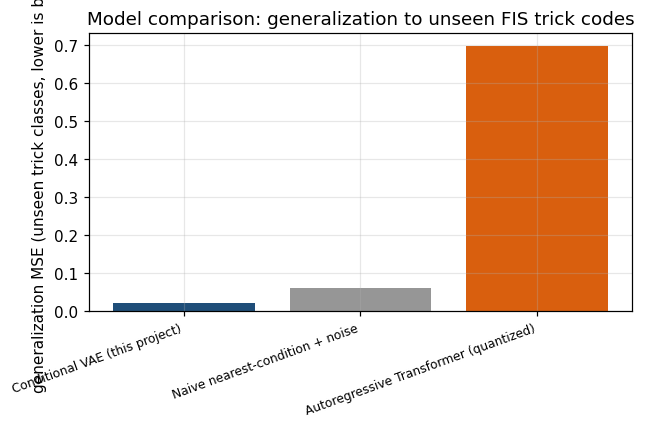

In [14]:
# ── 7.2b COMPARISON BAR CHART ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#969696", "#d95f0e", "#1f4e79"]
bars = ax.bar(comparison_df.model, comparison_df.generalization_MSE,
              color=[colors[["Naive nearest-condition + noise",
                              "Autoregressive Transformer (quantized)",
                              "Conditional VAE (this project)"].index(m)] for m in comparison_df.model])
ax.set_ylabel("generalization MSE (unseen trick classes, lower is better)")
ax.set_title("Model comparison: generalization to unseen FIS trick codes")
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 Physical Plausibility Check

A genuinely generated trick is only meaningful if its cumulative rotation matches the flip/twist count *defined by its own FIS code* -- this is a real, code-level constraint (not an invented benchmark). For each held-out trick class, we decode several samples from the CVAE prior and measure:

1. the mean absolute error between the generated final somersault angle and `n_flips × 360°`;
2. the mean absolute error between the generated final twist angle and `n_twists × 360°`;
3. the fraction of frames where the somersault angle briefly moves *backward* (a proxy for non-physical, jittery generation).

In [15]:
# ── 7.3 PHYSICAL PLAUSIBILITY CHECK ON HELD-OUT (UNSEEN) TRICK CLASSES ──────
def denorm_x(x_flat):
    return x_flat.reshape(T_STEPS, 3) * x_std + x_mean


@torch.no_grad()
def plausibility_check(model, cond_rows, n_samples=10):
    results = []
    for _, row in cond_rows.iterrows():
        c_raw = np.array([row.n_flips, row.n_twists, row.dd_score], dtype=np.float32)
        c_norm = (c_raw - c_mean) / c_std
        c_batch = torch.tensor(c_norm, dtype=torch.float32).unsqueeze(0).repeat(n_samples, 1)
        z = torch.randn(n_samples, LATENT_DIM)
        gen = model.decode(z, c_batch).numpy()

        errs_som, errs_twist, backward_frac = [], [], []
        for g in gen:
            seq = denorm_x(g)
            errs_som.append(abs(seq[-1, 0] - row.n_flips * 360))
            errs_twist.append(abs(seq[-1, 1] - row.n_twists * 360))
            d_som = np.diff(seq[:, 0])
            backward_frac.append((d_som < -5).mean())

        results.append({
            "trick_name": row.trick_name,
            "mean_abs_somersault_error_deg": np.mean(errs_som),
            "mean_abs_twist_error_deg": np.mean(errs_twist),
            "mean_backward_rotation_frac": np.mean(backward_frac),
        })
    return pd.DataFrame(results)


held_rows = fis_dd_table[fis_dd_table.trick_id.isin(HELD_OUT_TRICK_IDS)]
plausibility_df = plausibility_check(cvae, held_rows)
plausibility_df

,trick_name,mean_abs_somersault_error_deg,mean_abs_twist_error_deg,mean_backward_rotation_frac
0,Double Full-Full-Full (bFFbFbF),11.467786,18.597143,0.008475
1,Triple Full-Full-Full (bFFFbFbF),10.191846,27.397974,0.008475


### 7.4 Latent Space Structure

If the CVAE has learned a meaningful representation, the latent space should organize itself by trick difficulty even though it was never given trick identity as a label -- only the continuous `[n_flips, n_twists, dd_score]` condition and the raw kinematic sequence.

PCA explained variance ratio: [0.9763159  0.01803944]


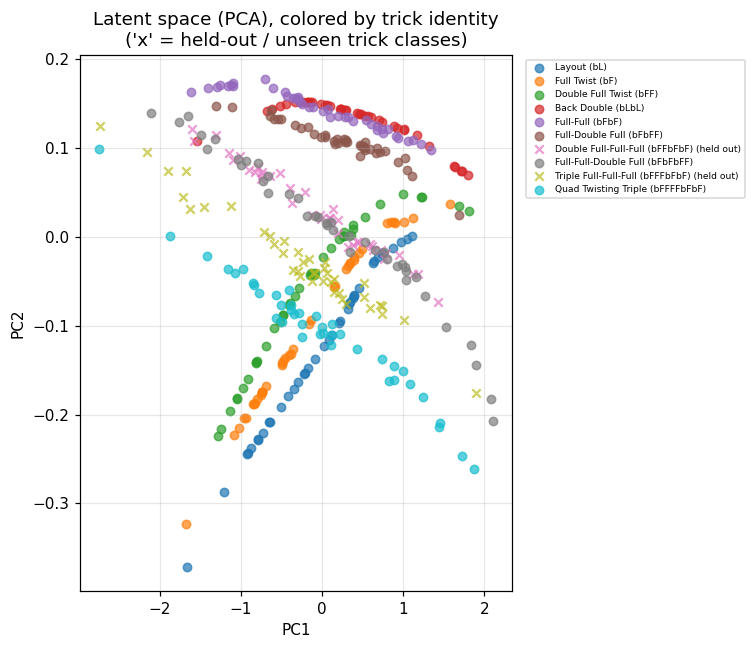

In [16]:
# ── 7.4 LATENT SPACE PCA, COLORED BY TRICK IDENTITY ─────────────────────────
cvae.eval()
with torch.no_grad():
    mu_all, _ = cvae.encode(X_t, C_t)
mu_np = mu_all.numpy()

pca = PCA(n_components=2, random_state=SEED)
mu_2d = pca.fit_transform(mu_np)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.get_cmap("tab10")
for tid in fis_dd_table.trick_id:
    mask = trick_ids == tid
    marker = "x" if tid in HELD_OUT_TRICK_IDS else "o"
    label = fis_dd_table.loc[fis_dd_table.trick_id == tid, "trick_name"].values[0]
    ax.scatter(mu_2d[mask, 0], mu_2d[mask, 1], color=cmap(tid % 10), marker=marker,
               s=30, alpha=0.7, label=f"{label}" + (" (held out)" if tid in HELD_OUT_TRICK_IDS else ""))
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Latent space (PCA), colored by trick identity\n('x' = held-out / unseen trick classes)")
ax.legend(fontsize=6, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

### 7.5 Latent Interpolation: Synthesizing a Novel Hybrid Trick

As a demonstration of genuine generative capability (not just reconstruction), we interpolate in latent space between a **Layout** (1 flip, 0 twists) and a **Full-Full** (2 flips, 2 twists), decoding five intermediate points to synthesize a smooth progression of increasingly complex "hybrid" tricks that were never in the training data as intermediate maneuvers.

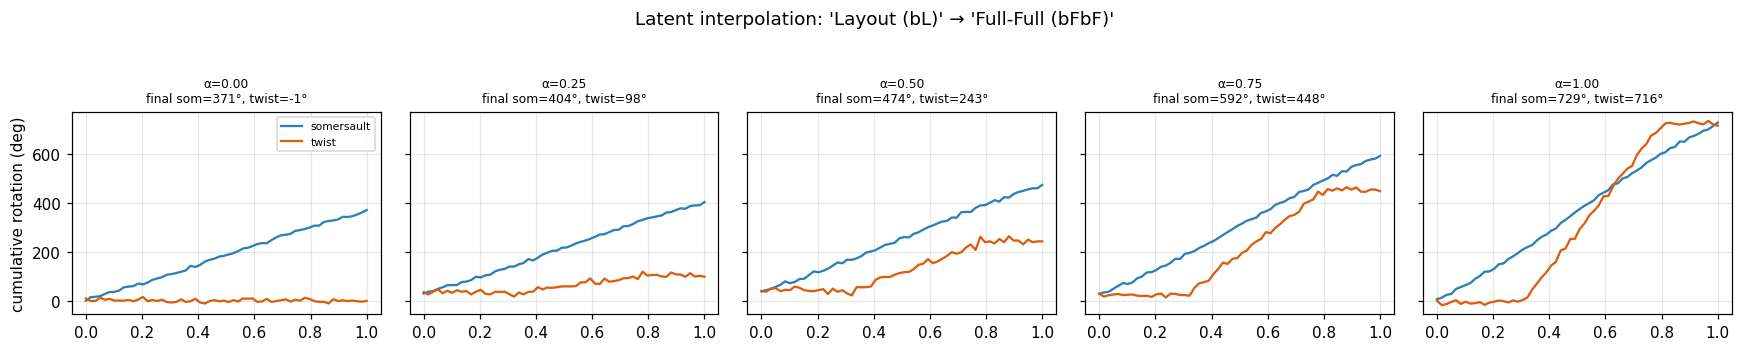

In [17]:
# ── 7.5 LATENT INTERPOLATION BETWEEN TWO REAL TRICKS ────────────────────────
@torch.no_grad()
def interpolate_tricks(model, row_a, row_b, n_steps=5):
    def get_c(row):
        c_raw = np.array([row.n_flips, row.n_twists, row.dd_score], dtype=np.float32)
        return (c_raw - c_mean) / c_std

    ca, cb = get_c(row_a), get_c(row_b)
    xa = torch.tensor(Xn.reshape(len(Xn), -1)[trick_ids == row_a.trick_id][0], dtype=torch.float32).unsqueeze(0)
    xb = torch.tensor(Xn.reshape(len(Xn), -1)[trick_ids == row_b.trick_id][0], dtype=torch.float32).unsqueeze(0)
    mu_a, _ = model.encode(xa, torch.tensor(ca).unsqueeze(0))
    mu_b, _ = model.encode(xb, torch.tensor(cb).unsqueeze(0))

    alphas = np.linspace(0, 1, n_steps)
    seqs = []
    for alpha in alphas:
        z = (1 - alpha) * mu_a + alpha * mu_b
        c_interp = torch.tensor((1 - alpha) * ca + alpha * cb, dtype=torch.float32).unsqueeze(0)
        x_gen = model.decode(z, c_interp)
        seqs.append(denorm_x(x_gen[0].numpy()))
    return alphas, seqs


row_a, row_b = fis_dd_table.iloc[0], fis_dd_table.iloc[4]  # Layout -> Full-Full
alphas, interp_seqs = interpolate_tricks(cvae, row_a, row_b)

fig, axes = plt.subplots(1, len(alphas), figsize=(16, 3), sharey=True)
t_axis = np.linspace(0, 1, T_STEPS)
for ax, a, seq in zip(axes, alphas, interp_seqs):
    ax.plot(t_axis, seq[:, 0], color="#2c7fb8", label="somersault")
    ax.plot(t_axis, seq[:, 1], color="#d95f0e", label="twist")
    ax.set_title(f"α={a:.2f}\nfinal som={seq[-1,0]:.0f}°, twist={seq[-1,1]:.0f}°", fontsize=8)
axes[0].set_ylabel("cumulative rotation (deg)")
axes[0].legend(fontsize=7)
fig.suptitle(f"Latent interpolation: '{row_a.trick_name}' → '{row_b.trick_name}'", y=1.05)
plt.tight_layout()
plt.show()

### 7.6 Visualizing a Generated Trick as a Skeleton Storyboard

To make a generated trajectory tangible, we render a highly simplified stick-figure skier whose body rotation follows the generated somersault angle and whose limb configuration follows the generated tuck factor, sampled at six evenly spaced points across the flight phase.

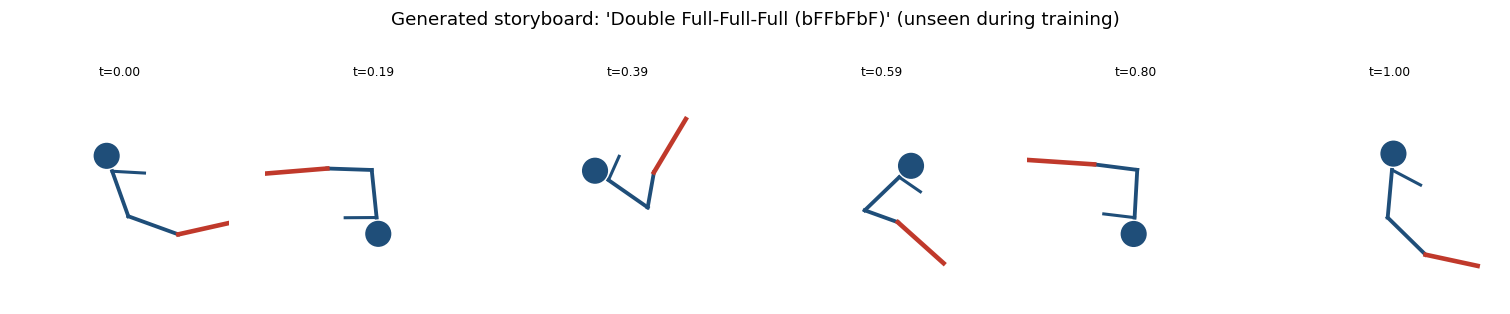

In [18]:
# ── 7.6 SIMPLIFIED STICK-FIGURE SKIER STORYBOARD ────────────────────────────
def draw_skier(ax, cx, cy, somersault_deg, tuck_factor, scale=1.0, color="#1f4e79"):
    """Draw a simplified stick-figure skier at a given rotation/tuck state."""
    theta = np.radians(somersault_deg)
    tuck = tuck_factor

    torso_len = 0.35 * scale
    leg_len = (0.45 - 0.22 * tuck) * scale
    arm_len = (0.30 - 0.12 * tuck) * scale
    ski_len = 0.5 * scale

    def rot(x, y):
        xr = x * np.cos(theta) - y * np.sin(theta)
        yr = x * np.sin(theta) + y * np.cos(theta)
        return cx + xr, cy + yr

    hip = rot(0, -torso_len / 2)
    shoulder = rot(0, torso_len / 2)
    head = rot(0, torso_len / 2 + 0.12 * scale)

    knee_angle = np.radians(20 + 110 * tuck)
    foot = rot(np.sin(knee_angle) * leg_len, -torso_len / 2 - np.cos(knee_angle) * leg_len)

    arm_angle = np.radians(30 + 90 * tuck)
    hand = rot(np.sin(arm_angle) * arm_len, torso_len / 2 - np.cos(arm_angle) * arm_len * 0.6)

    ski_tip = rot(np.sin(knee_angle) * leg_len + np.sin(knee_angle) * ski_len,
                  -torso_len / 2 - np.cos(knee_angle) * leg_len - np.cos(knee_angle) * ski_len * 0.15)

    ax.plot(*zip(hip, shoulder), color=color, lw=2.5)
    ax.plot(*zip(hip, foot), color=color, lw=2.5)
    ax.plot(*zip(shoulder, hand), color=color, lw=2)
    ax.plot(*zip(foot, ski_tip), color="#c0392b", lw=3)
    ax.add_patch(plt.Circle(head, 0.09 * scale, color=color))


# Generate one sample for the held-out "Double Full-Full-Full" trick and render its storyboard
row = fis_dd_table[fis_dd_table.trick_name.str.contains("Double Full-Full-Full")].iloc[0]
c_raw = np.array([row.n_flips, row.n_twists, row.dd_score], dtype=np.float32)
c_norm = torch.tensor((c_raw - c_mean) / c_std, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    z_sample = torch.randn(1, LATENT_DIM)
    gen_seq = denorm_x(cvae.decode(z_sample, c_norm)[0].numpy())

frame_indices = np.linspace(0, T_STEPS - 1, 6).astype(int)
fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for ax, fi in zip(axes, frame_indices):
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    ax.set_aspect("equal")
    ax.axis("off")
    draw_skier(ax, 0, 0, gen_seq[fi, 0], np.clip(gen_seq[fi, 2], 0, 1))
    ax.set_title(f"t={fi/(T_STEPS-1):.2f}", fontsize=8)
fig.suptitle(f"Generated storyboard: '{row.trick_name}' (unseen during training)", y=1.08)
plt.tight_layout()
plt.show()